# Insurance Lead Conversion Prediction 
## Project Goal
Predict whether a lead will convert (buy a policy) based on demographic, behavioural, and pricing features.

## Dataset
- 10,000 leads
- 27 features
- Target: `Conversion_Status` (1 = bought, 0 = didn't buy)

## Phase 1: Exploratory Data Analysis
### Step 1: Load Data and Initial Inspection
We first load the data and answer:
- How many rows and columns do we have?
- What are the data types of each column?
- Are there any missing values?

In [1]:
## Load and Inspect

import pandas as pd 

df = pd.read_csv("synthetic_insurance_data.csv")

# first look
df.head()

,Age,Is_Senior,Marital_Status,Married_Premium_Discount,Prior_Insurance,Prior_Insurance_Premium_Adjustment,Claims_Frequency,Claims_Severity,Claims_Adjustment,Policy_Type,...,Time_Since_First_Contact,Conversion_Status,Website_Visits,Inquiries,Quotes_Requested,Time_to_Conversion,Credit_Score,Premium_Adjustment_Credit,Region,Premium_Adjustment_Region
0,47,0,Married,86,1-5 years,50,0,Low,0,Full Coverage,...,10,0,5,1,2,99,704,-50,Suburban,50
1,37,0,Married,86,1-5 years,50,0,Low,0,Full Coverage,...,22,0,5,1,2,99,726,-50,Urban,100
2,49,0,Married,86,1-5 years,50,1,Low,50,Full Coverage,...,28,0,4,4,1,99,772,-50,Urban,100
3,62,1,Married,86,>5 years,0,1,Low,50,Full Coverage,...,4,1,6,2,2,2,809,-50,Urban,100
4,36,0,Single,0,>5 years,0,2,Low,100,Full Coverage,...,14,1,8,4,2,10,662,50,Suburban,50


### Inspection: Shape, Types, Nulls, and Basic Statistics
Before any analysis, we need to understand the structure of our data.
- `shape` tells us rows and columns
- `info()` tells us data types and null counts
- `describe()` gives us statistical summaries of numeric columns

In [2]:
# shape
print("Shape:")
print(df.shape)
print()

# data types and nulls
print("Info:")
df.info()
print()

# basic stats
print("Stats:")
df.describe()

Shape:
(10000, 27)

Info:
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 27 columns):
 #   Column                              Non-Null Count  Dtype
---  ------                              --------------  -----
 0   Age                                 10000 non-null  int64
 1   Is_Senior                           10000 non-null  int64
 2   Marital_Status                      10000 non-null  str  
 3   Married_Premium_Discount            10000 non-null  int64
 4   Prior_Insurance                     10000 non-null  str  
 5   Prior_Insurance_Premium_Adjustment  10000 non-null  int64
 6   Claims_Frequency                    10000 non-null  int64
 7   Claims_Severity                     10000 non-null  str  
 8   Claims_Adjustment                   10000 non-null  int64
 9   Policy_Type                         10000 non-null  str  
 10  Policy_Adjustment                   10000 non-null  int64
 11  Premium_Amount                      10000 non-null  i

,Age,Is_Senior,Married_Premium_Discount,Prior_Insurance_Premium_Adjustment,Claims_Frequency,Claims_Adjustment,Policy_Adjustment,Premium_Amount,Safe_Driver_Discount,Multi_Policy_Discount,...,Total_Discounts,Time_Since_First_Contact,Conversion_Status,Website_Visits,Inquiries,Quotes_Requested,Time_to_Conversion,Credit_Score,Premium_Adjustment_Credit,Premium_Adjustment_Region
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,...,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,39.991700,0.159300,42.131400,47.625000,0.497200,36.780000,-79.860000,2219.571400,0.199900,0.305100,...,30.110000,15.478000,0.576700,5.022900,1.996900,1.996900,46.07320,714.253400,-11.320000,64.325000
std,14.050358,0.365974,42.993376,34.354438,0.716131,65.910288,97.955806,148.521132,0.399945,0.460473,...,33.689782,8.677975,0.494107,2.238231,1.415588,0.817409,45.44845,49.749487,48.704156,39.232618
min,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-200.000000,1800.000000,0.000000,0.000000,...,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.00000,530.000000,-50.000000,0.000000
25%,29.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-200.000000,2100.000000,0.000000,0.000000,...,0.000000,8.000000,0.000000,3.000000,1.000000,1.000000,6.00000,681.000000,-50.000000,50.000000
50%,39.000000,0.000000,0.000000,50.000000,0.000000,0.000000,0.000000,2236.000000,0.000000,0.000000,...,50.000000,16.000000,1.000000,5.000000,2.000000,2.000000,12.00000,715.000000,-50.000000,50.000000
75%,50.000000,0.000000,86.000000,50.000000,1.000000,50.000000,0.000000,2336.000000,0.000000,1.000000,...,50.000000,23.000000,1.000000,6.000000,3.000000,3.000000,99.00000,748.000000,50.000000,100.000000
max,90.000000,1.000000,86.000000,100.000000,5.000000,800.000000,0.000000,2936.000000,1.000000,1.000000,...,150.000000,30.000000,1.000000,16.000000,9.000000,3.000000,99.00000,850.000000,50.000000,100.000000


### Inspection Findings

We observed the following from the initial data inspection:

- **Zero missing values** across all 27 columns — no imputation required.
- **21 numeric columns** (`int64`) and **6 categorical columns** (`str`): `Marital_Status`, 
  `Prior_Insurance`, `Claims_Severity`, `Policy_Type`, `Source_of_Lead`, `Region` — 
  these must be encoded before modelling.
- **`Time_to_Conversion` is a leaky feature** — it records days to purchase for converters 
  and 99 for non-converters, meaning it encodes the target directly. It will be dropped 
  in feature engineering.
- **`Claims_Adjustment`** is heavily right-skewed — most leads have low claims, 
  a few have very high values. We will revisit this during univariate analysis.
- **Discount columns** (`Safe_Driver_Discount`, `Multi_Policy_Discount`, `Bundling_Discount`) 
  are binary flags stored as integers — we will treat them accordingly.

## EDA Step 2: Univariate Analysis
We examine each feature individually to understand its distribution, detect skewness, 
spot outliers, and identify anything unusual before modelling.

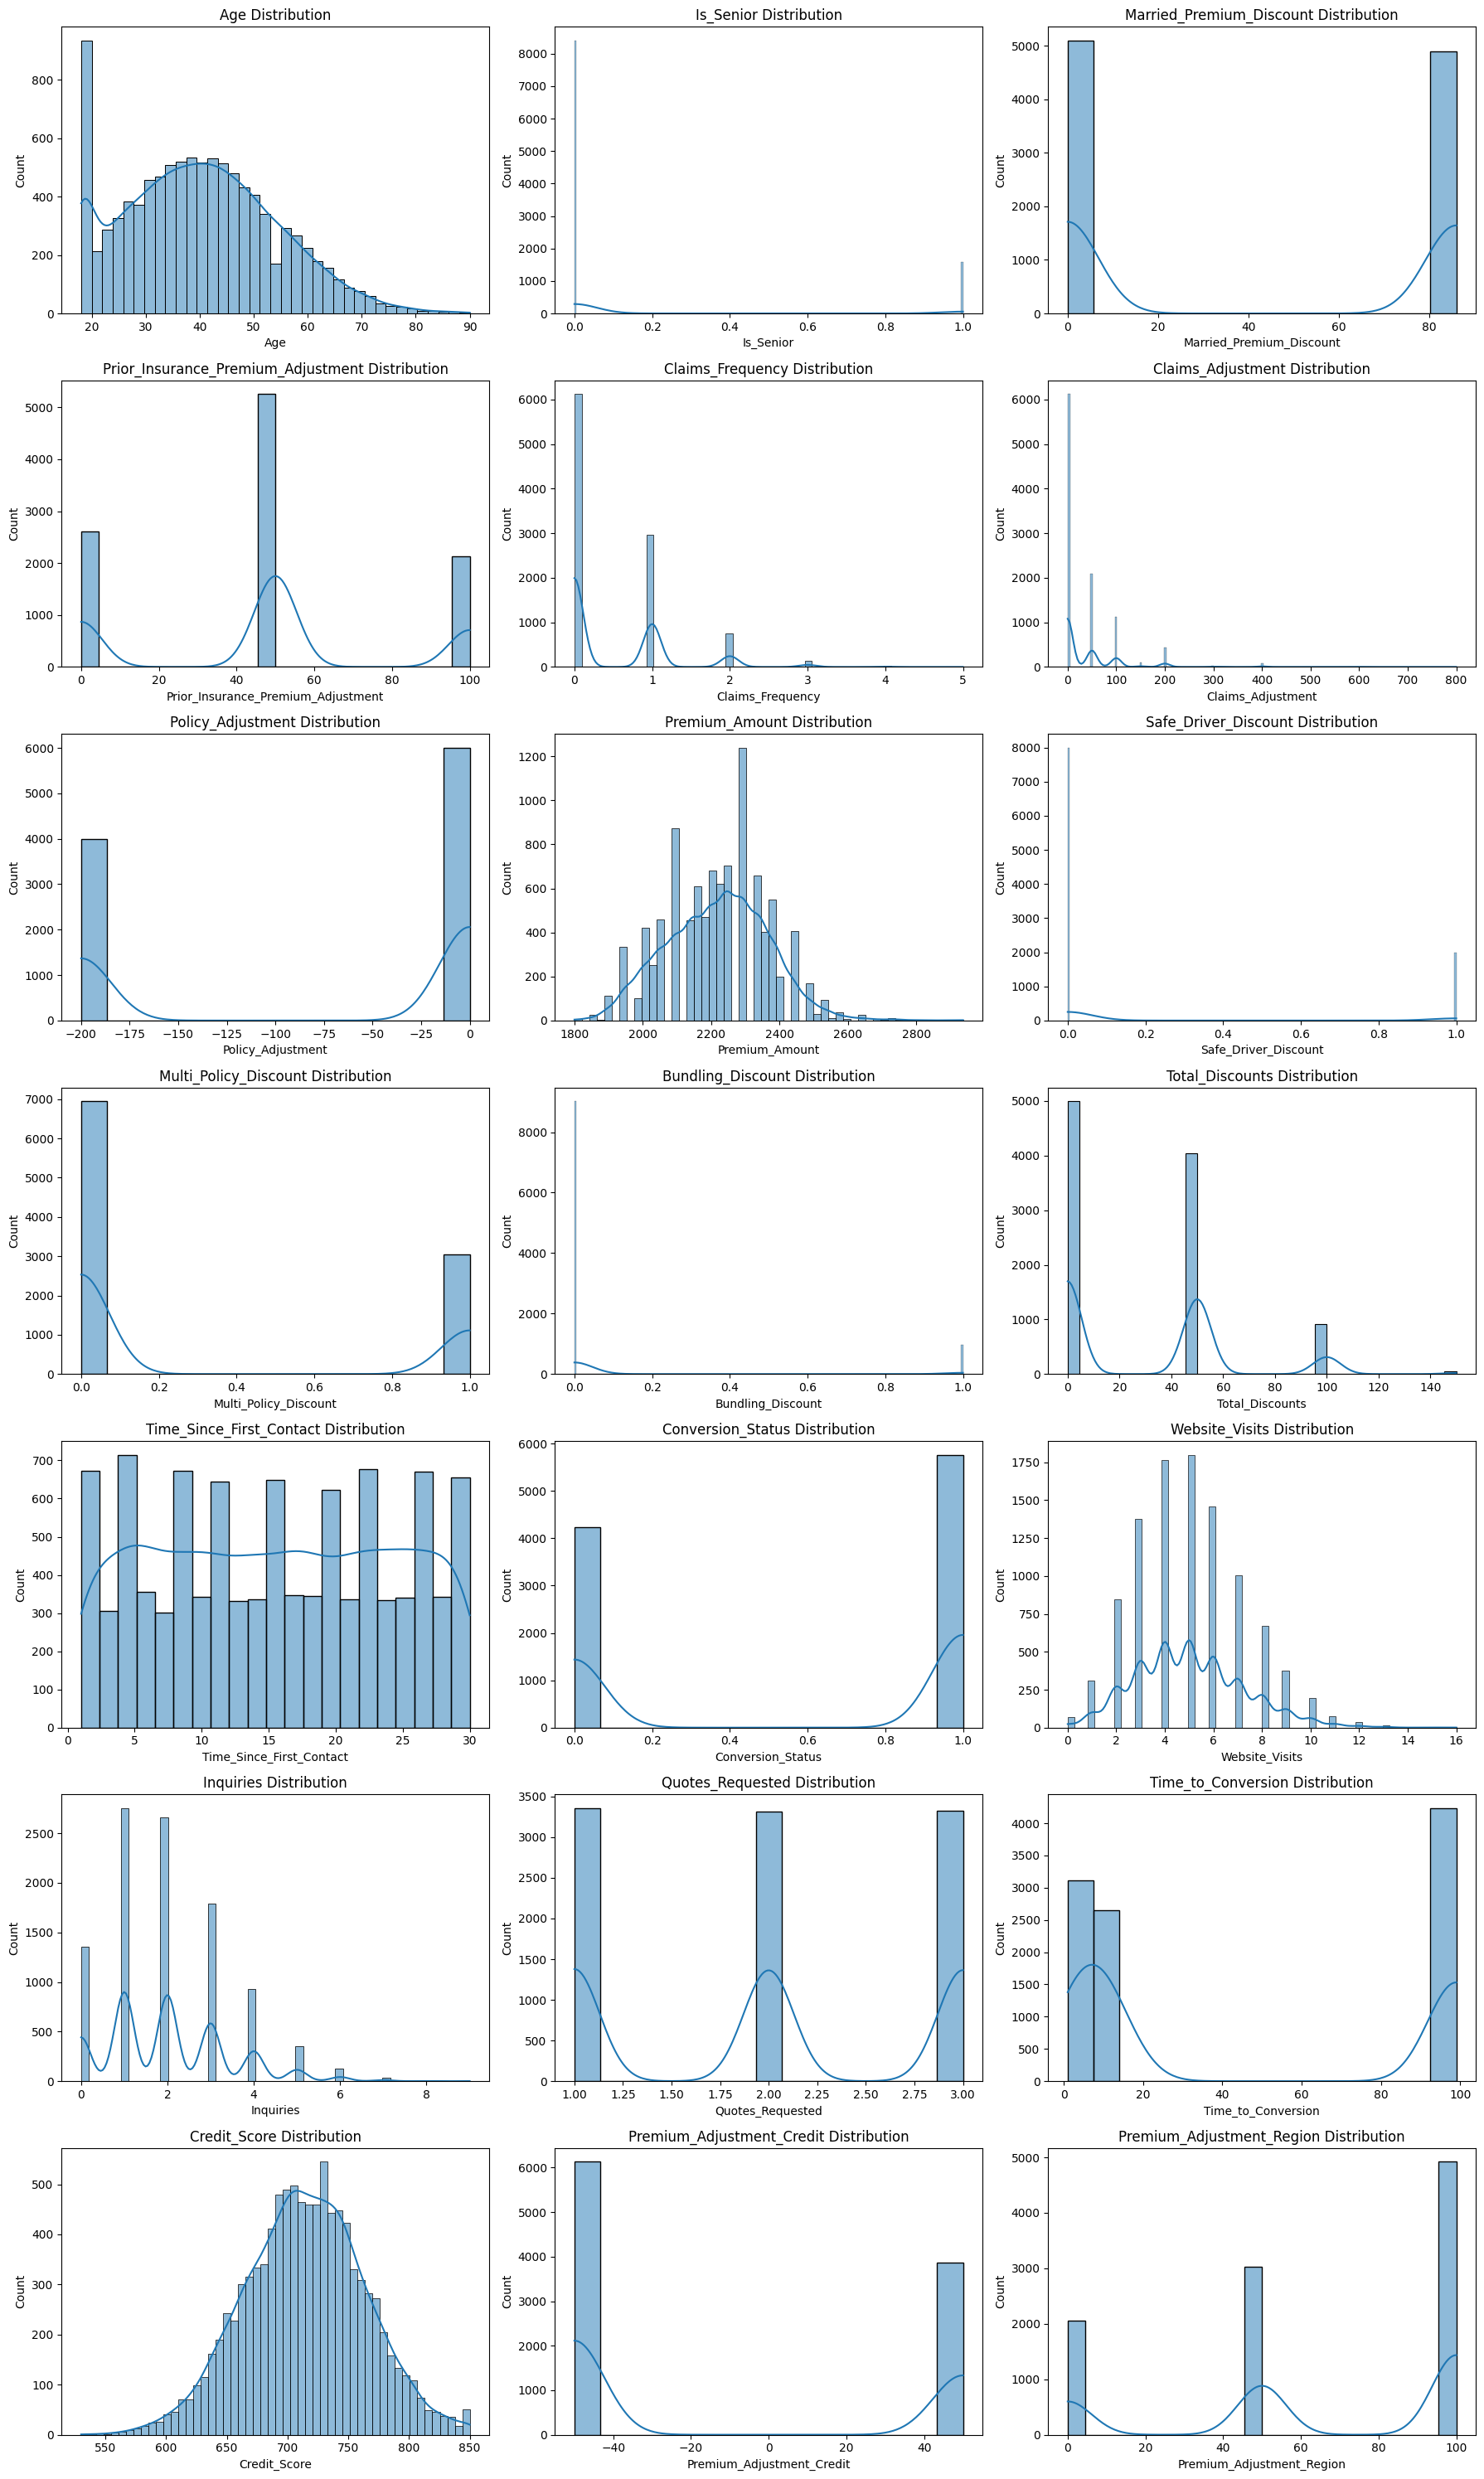

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

df_numeric = df.select_dtypes(include='number').columns

fig, axes = plt.subplots(7, 3, figsize=(18, 30))

for i, col in enumerate(df_numeric):
    ax = axes.flatten()[i]
    sns.histplot(df[col], ax=ax, kde=True)
    ax.set_title(f"{col} Distribution")
    ax.set_xlabel(col)
plt.tight_layout()
plt.show()

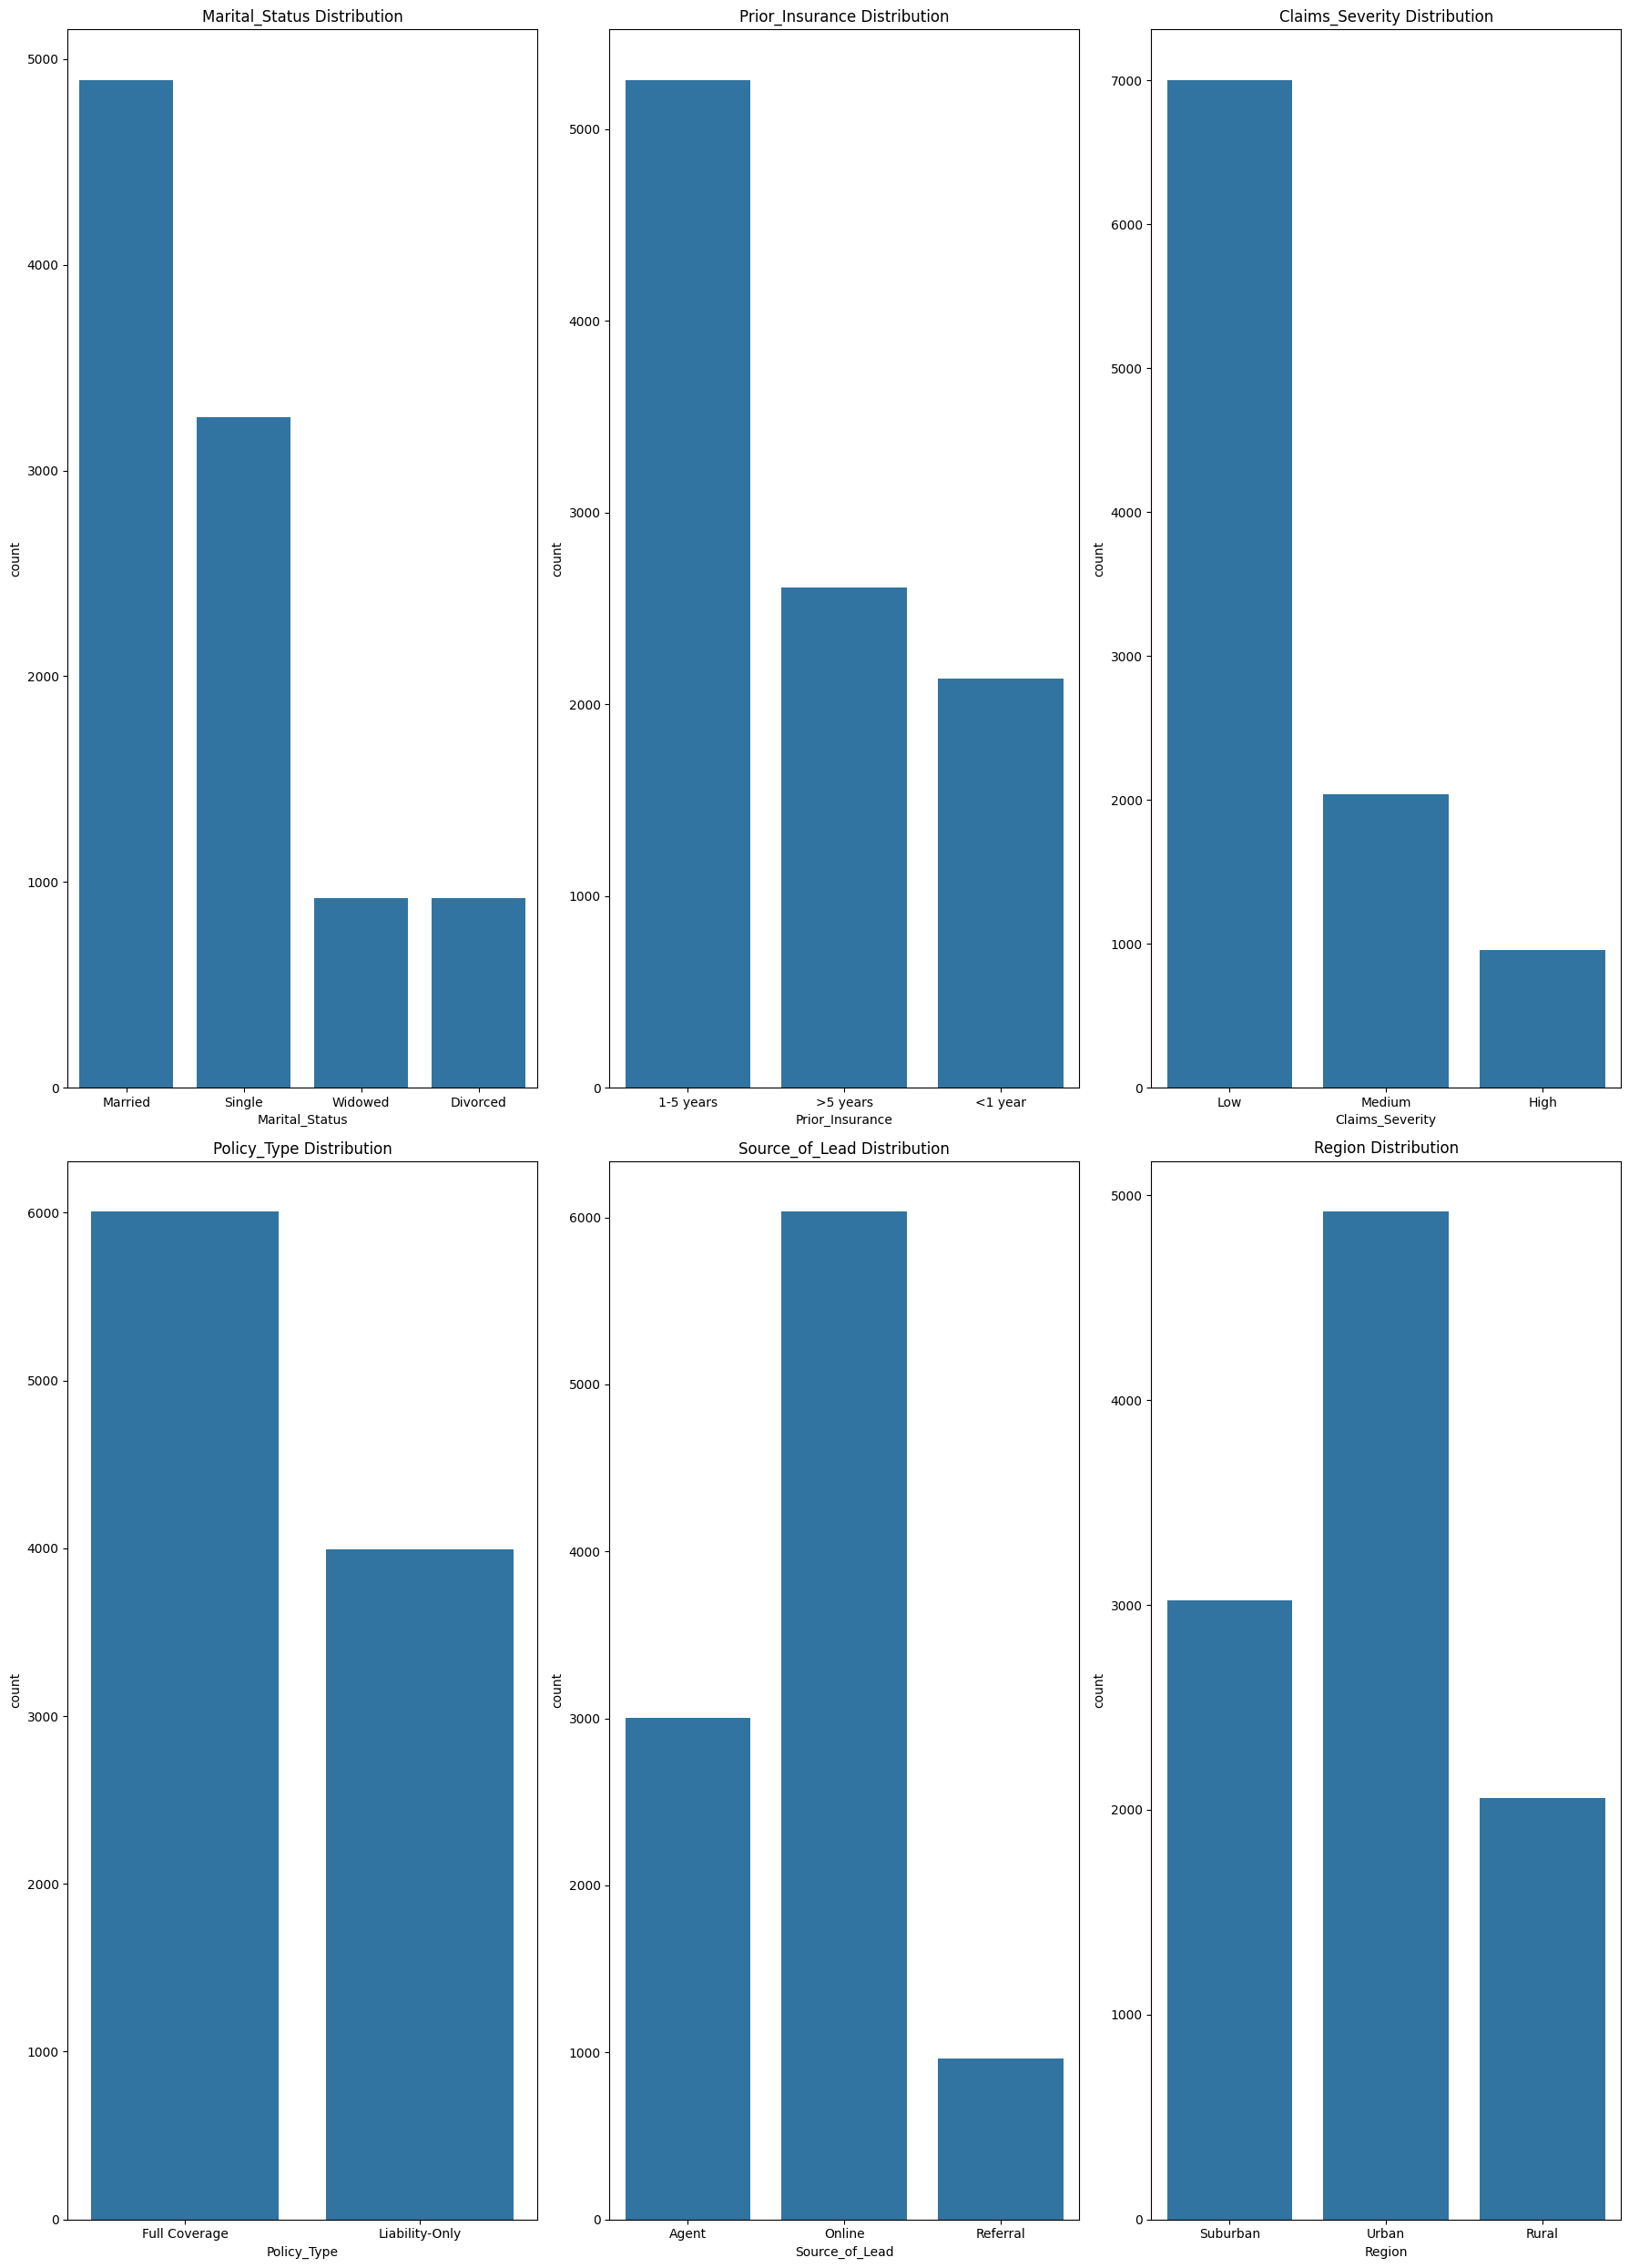

In [4]:
df_categorical = df.select_dtypes(include='str').columns
fig, axes = plt.subplots(2, 3, figsize=(18, 25))

for i, col in enumerate(df_categorical):
    ax = axes.flatten()[i]
    sns.countplot(data=df, x=col, ax=ax)
    ax.set_title(f"{col} Distribution")
    ax.set_xlabel(col)
plt.tight_layout()
plt.show()

### Univariate Analysis Findings

**Numeric Columns:**
- `Age`, `Credit_Score`, and `Premium_Amount` are approximately normally distributed.
- `Married_Premium_Discount`, `Policy_Adjustment`, `Prior_Insurance_Premium_Adjustment`,
  `Premium_Adjustment_Credit`, and `Premium_Adjustment_Region` are bimodal/multimodal —
  they represent discrete business rules encoded as numbers, not truly continuous variables.
- `Claims_Frequency` and `Claims_Adjustment` are heavily right-skewed — most leads have 
  zero or low claims, with a few extreme high values.
- `Time_to_Conversion` confirms target leakage — two distinct spikes at low values 
  (converters) and 99 (non-converters). Will be dropped in feature engineering.
- `Is_Senior`, `Safe_Driver_Discount`, `Multi_Policy_Discount`, and `Bundling_Discount` 
  are binary flags stored as integers.

**Categorical Columns:**
- `Marital_Status` — Married dominates, followed by Single. Divorced and Separated are minorities.
- `Prior_Insurance` — 1-5 years is most common, followed by >5 years and <1 year.
- `Claims_Severity` — Low dominates heavily. High is rare.
- `Policy_Type` — Full Coverage slightly dominates over Liability-Only.
- `Source_of_Lead` — Online dominates. Referral is smallest.
- `Region` — Urban dominates. Rural is smallest.

## EDA Step 3: Bivariate Analysis
We now compare every feature against `Conversion_Status` to answer: **which features actually influence whether a lead converts?**

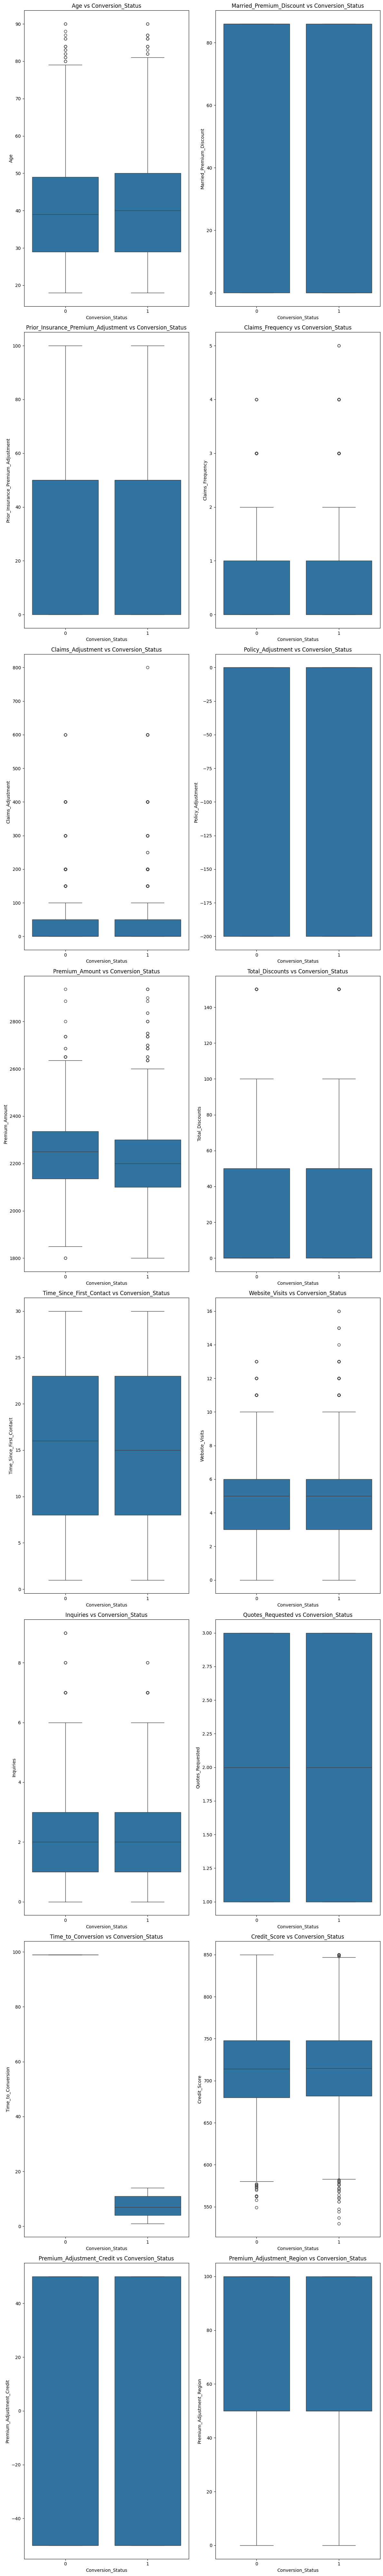

In [5]:
# for numeric vs target

fig, axes = plt.subplots(8, 2, figsize=(12, 80))

cols_to_exclude = ['Is_Senior', 'Safe_Driver_Discount', 'Multi_Policy_Discount', 
'Bundling_Discount', 'Conversion_Status']
cols_to_plot = [col for col in df_numeric if col not in cols_to_exclude]

for i, col in enumerate(cols_to_plot):
    ax = axes.flatten()[i]
    sns.boxplot(x=df['Conversion_Status'].astype(str), y=col, data=df, ax=ax)
    ax.set_title(f"{col} vs Conversion_Status")
    ax.set_xlabel('Conversion_Status')
    ax.set_ylabel(col)
plt.tight_layout()
plt.show()

### Bivariate Analysis: Numeric Features vs Conversion Status

We compared each numeric feature against `Conversion_Status` using boxplots.

Key findings:
- Almost all numeric features show **no meaningful separation** between converters and 
  non-converters — their distributions are nearly identical across both groups.
- `Premium_Amount` shows a subtle difference — converters tend to have a **slightly lower 
  median premium**, suggesting lower-priced policies are easier to commit to.
- `Time_to_Conversion` confirms target leakage — non-converters have no real distribution 
  while converters cluster tightly at low values. This feature will be dropped.

This tells us the model must learn feature **combinations**, not individual signals — 
pointing us toward ensemble methods like Random Forest or XGBoost in modelling.

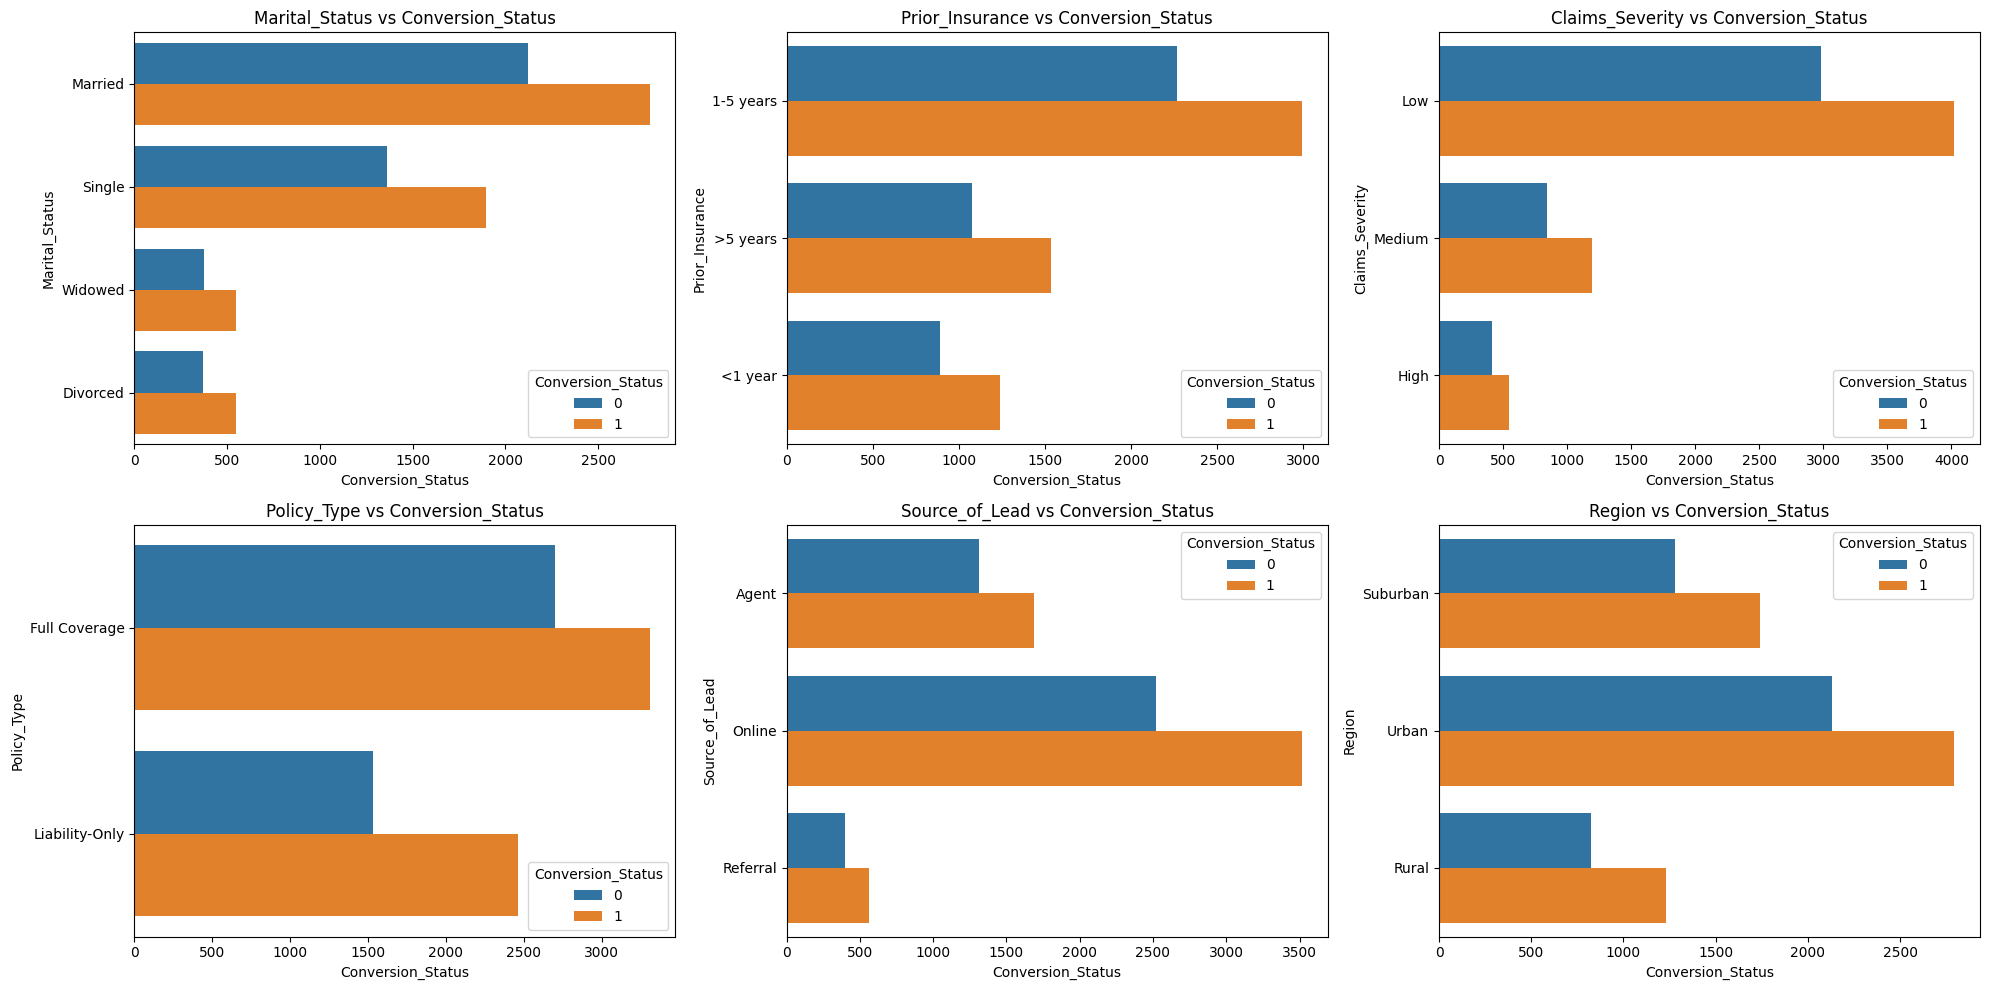

In [6]:
# for numeric vs target

fig, axes = plt.subplots(2, 3, figsize=(20, 10))

for i, col in enumerate(df_categorical):
    ax = axes.flatten()[i]
    sns.countplot(hue='Conversion_Status', y=col, data=df, ax=ax)
    ax.set_title(f"{col} vs Conversion_Status")
    ax.set_xlabel('Conversion_Status')
    ax.set_ylabel(col)
plt.tight_layout()
plt.show()

### Bivariate Analysis: Categorical Features vs Conversion Status

We compared each categorical feature against `Conversion_Status` using countplots.

- `Marital_Status` — Married and Single leads convert more; Widowed and Divorced convert less.
- `Prior_Insurance` — Leads with 1-5 years prior insurance convert most; 
  those with less than 1 year convert least.
- `Claims_Severity` — Low severity leads convert most; high severity leads convert least.
- `Policy_Type` — Full Coverage leads convert more than Liability-Only.
- `Source_of_Lead` — Online leads dominate conversions; Referral converts least.
- `Region` — Urban leads convert most; Rural leads convert least.

Categorical features show clearer separation than numeric features, 
making them important predictors for the model.

### EDA Step 4: Correlation Analysis
Before feature engineering, we need to check multicollinearity - whether any numeric features are highly correlated with each other.

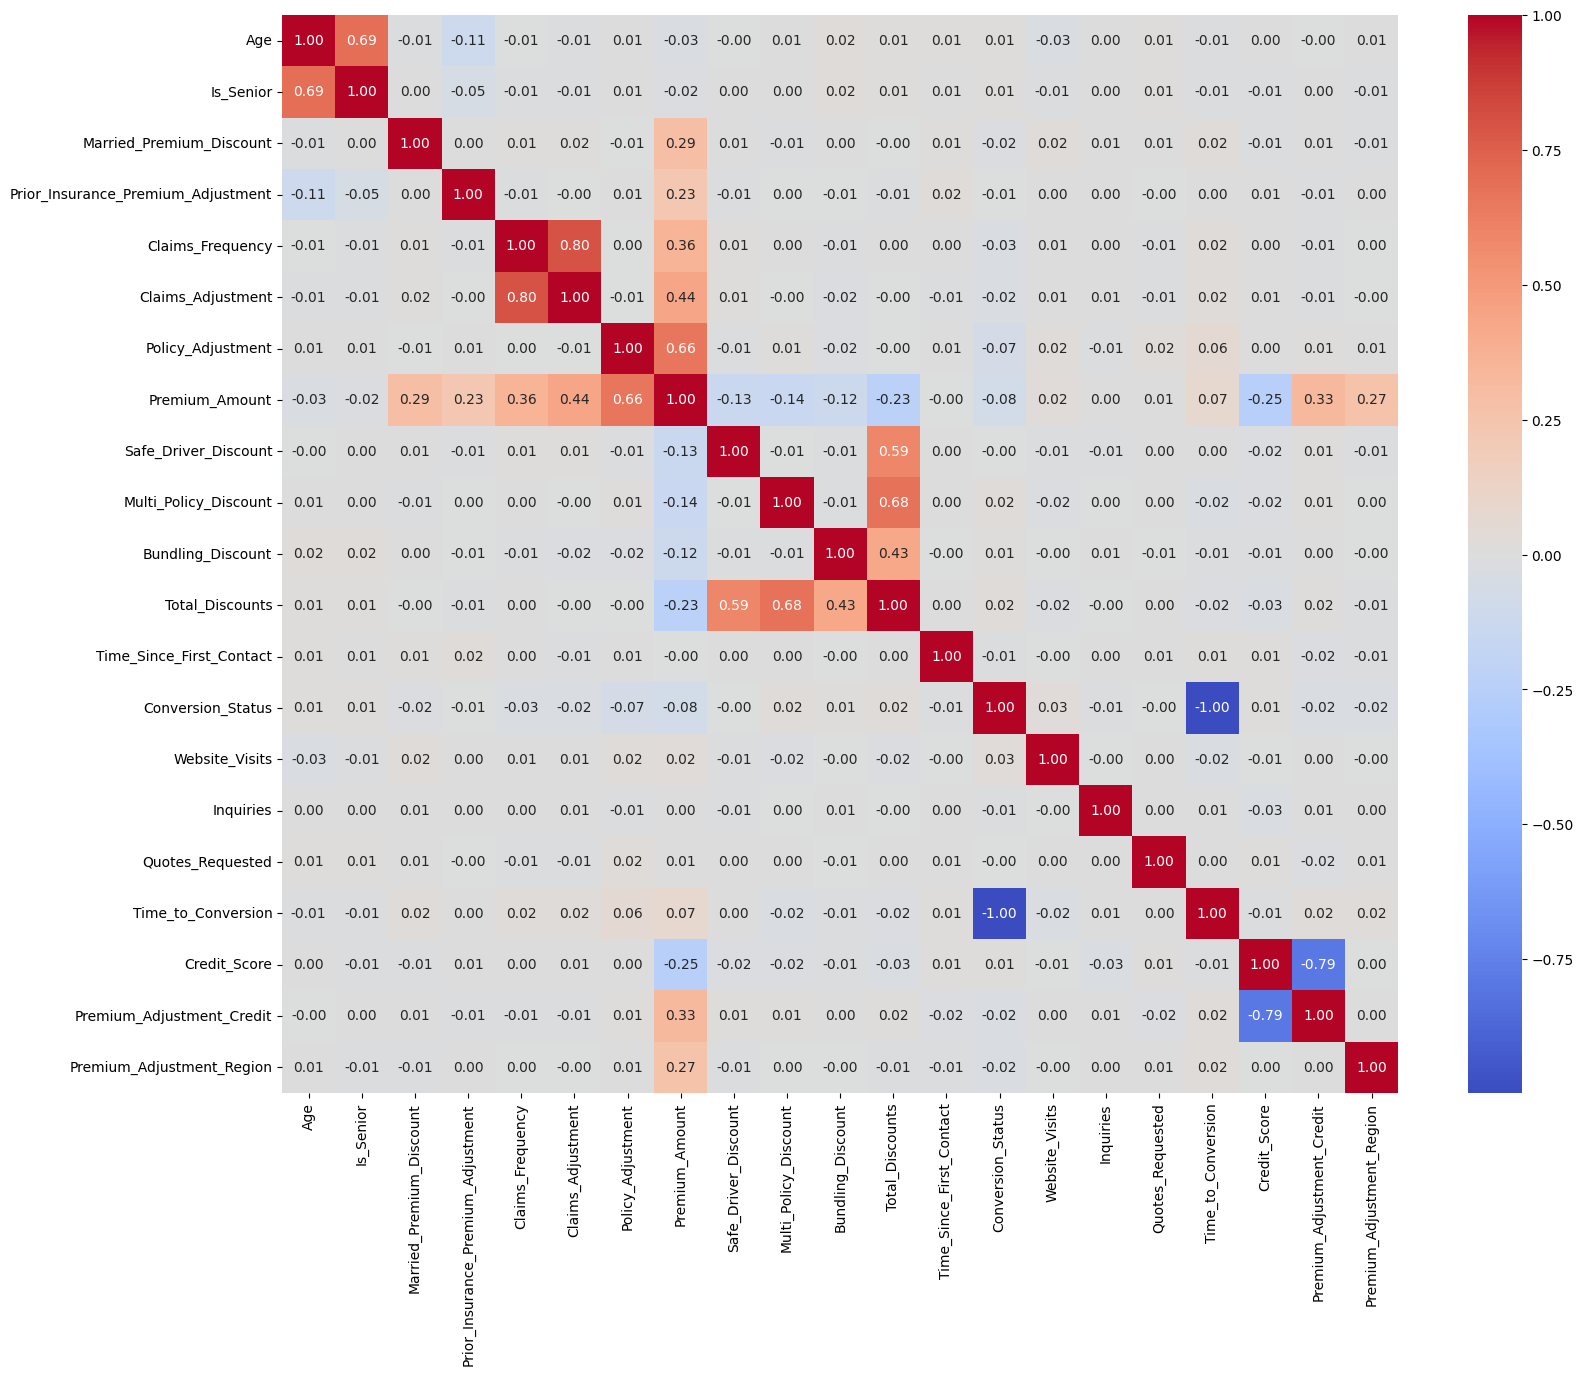

In [7]:
# correlation heatmap
plt.figure(figsize=(18, 14))
sns.heatmap(df[df_numeric].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.show()

### Correlation Analysis

We examined pairwise correlations between all numeric features using a heatmap.

- `Age` and `Is_Senior` are strongly correlated (0.69) — expected by definition.
- `Claims_Frequency` and `Claims_Adjustment` are highly correlated (0.80) — 
  more claims directly drive higher adjustments.
- The three discount flags (`Safe_Driver`, `Multi_Policy`, `Bundling`) all correlate 
  strongly with `Total_Discounts` (0.59, 0.68, 0.43) — since `Total_Discounts` 
  is their sum, it carries redundant information and will be dropped.
- `Credit_Score` and `Premium_Adjustment_Credit` show strong inverse correlation (-0.79) — 
  higher credit scores reduce premium adjustments as expected.
- `Time_to_Conversion` and `Conversion_Status` show perfect negative correlation (-1.00) — 
  final confirmation of target leakage. This feature will be dropped.

## Phase 2: Feature Engineering
This is where we prepare for data modeling.

In [8]:
# drop leaky and redundant features
df = df.drop(["Time_to_Conversion", "Total_Discounts"], axis=1)

# encode categorical features
df_final = pd.get_dummies(df, columns=df_categorical, drop_first=True)

# separate features and target
X = df_final.drop(["Conversion_Status"], axis=1)
y = df_final["Conversion_Status"]

# scale numeric features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [9]:
# verification to confirm the encdoing worked and new columns were created

# shape of df_final
print("Shape:")
print(df_final.shape)

print("Column names:")
print(df_final.columns)

Shape:
(10000, 31)
Column names:
Index(['Age', 'Is_Senior', 'Married_Premium_Discount',
       'Prior_Insurance_Premium_Adjustment', 'Claims_Frequency',
       'Claims_Adjustment', 'Policy_Adjustment', 'Premium_Amount',
       'Safe_Driver_Discount', 'Multi_Policy_Discount', 'Bundling_Discount',
       'Time_Since_First_Contact', 'Conversion_Status', 'Website_Visits',
       'Inquiries', 'Quotes_Requested', 'Credit_Score',
       'Premium_Adjustment_Credit', 'Premium_Adjustment_Region',
       'Marital_Status_Married', 'Marital_Status_Single',
       'Marital_Status_Widowed', 'Prior_Insurance_<1 year',
       'Prior_Insurance_>5 years', 'Claims_Severity_Low',
       'Claims_Severity_Medium', 'Policy_Type_Liability-Only',
       'Source_of_Lead_Online', 'Source_of_Lead_Referral', 'Region_Suburban',
       'Region_Urban'],
      dtype='str')


### Feature Engineering

We prepared the data for modelling in four steps:

- Dropped `Time_to_Conversion` (target leakage) and `Total_Discounts` (redundant — sum of discount flags).
- Encoded 6 categorical columns using one-hot encoding (`drop_first=True` to avoid multicollinearity) — expanding them into 10 binary columns.
- Separated features (`X`) and target (`y`).
- Scaled all features using `StandardScaler` so no feature dominates by magnitude.

Final feature matrix shape: (10000, 31).

## Phase 3: Model Building

We train three models of increasing complexity and compare performance:
- **Logistic Regression** — interpretable linear baseline
- **Random Forest** — ensemble of decision trees, handles feature interactions
- **XGBoost** — gradient boosting, typically strongest on tabular data

We split 80% for training and 20% for testing before training any model.

In [10]:
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LogisticRegression 
from sklearn.ensemble import RandomForestClassifier 
from xgboost import XGBClassifier 

# train test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# instantiate all three models
lr = LogisticRegression()
rf = RandomForestClassifier()
xgb = XGBClassifier()

In [11]:
# fit the logistic regression model
lr.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [12]:
# fit the random forest classifier model
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [13]:
# fit the XGBoost classifier
xgb.fit(X_train, y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_meth

In [14]:
# get predictions for the three models
lr_pred = lr.predict(X_test)
rf_pred = rf.predict(X_test)
xgb_pred = xgb.predict(X_test)

In [15]:
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

In [16]:
# evaluation for the Logistic Regression model

print(f"Accuracy Score: {accuracy_score(y_test, lr_pred):.2f}\n")
print(f"Classification Report: \n{classification_report(y_test, lr_pred)}\n")
print(f"ROC AUC Score: {roc_auc_score(y_test, lr_pred):.2f}")

Accuracy Score: 0.57

Classification Report: 
              precision    recall  f1-score   support

           0       0.48      0.04      0.07       860
           1       0.57      0.97      0.72      1140

    accuracy                           0.57      2000
   macro avg       0.53      0.50      0.39      2000
weighted avg       0.53      0.57      0.44      2000


ROC AUC Score: 0.50


In [17]:
# evaluation for the RandomForestClassifer model

print(f"Accuracy Score: {accuracy_score(y_test, rf_pred):.2f}\n")
print(f"Classification Report: \n{classification_report(y_test, rf_pred)}\n")
print(f"ROC AUC Score: {roc_auc_score(y_test, rf_pred):.2f}")

Accuracy Score: 0.55

Classification Report: 
              precision    recall  f1-score   support

           0       0.46      0.26      0.33       860
           1       0.58      0.77      0.66      1140

    accuracy                           0.55      2000
   macro avg       0.52      0.51      0.50      2000
weighted avg       0.53      0.55      0.52      2000


ROC AUC Score: 0.51


In [18]:
# evaluation for the XGBoost model

print(f"Accuracy Score: {accuracy_score(y_test, xgb_pred):.2f}\n")
print(f"Classification Report: \n{classification_report(y_test, xgb_pred)}\n")
print(f"ROC AUC Score: {roc_auc_score(y_test, xgb_pred):.2f}")

Accuracy Score: 0.53

Classification Report: 
              precision    recall  f1-score   support

           0       0.44      0.31      0.36       860
           1       0.57      0.70      0.63      1140

    accuracy                           0.53      2000
   macro avg       0.51      0.50      0.50      2000
weighted avg       0.52      0.53      0.52      2000


ROC AUC Score: 0.50


In [19]:
print(X_train.shape)
print([col for col in df_final.columns if 'Time_to_Conversion' in col])

(8000, 30)
[]


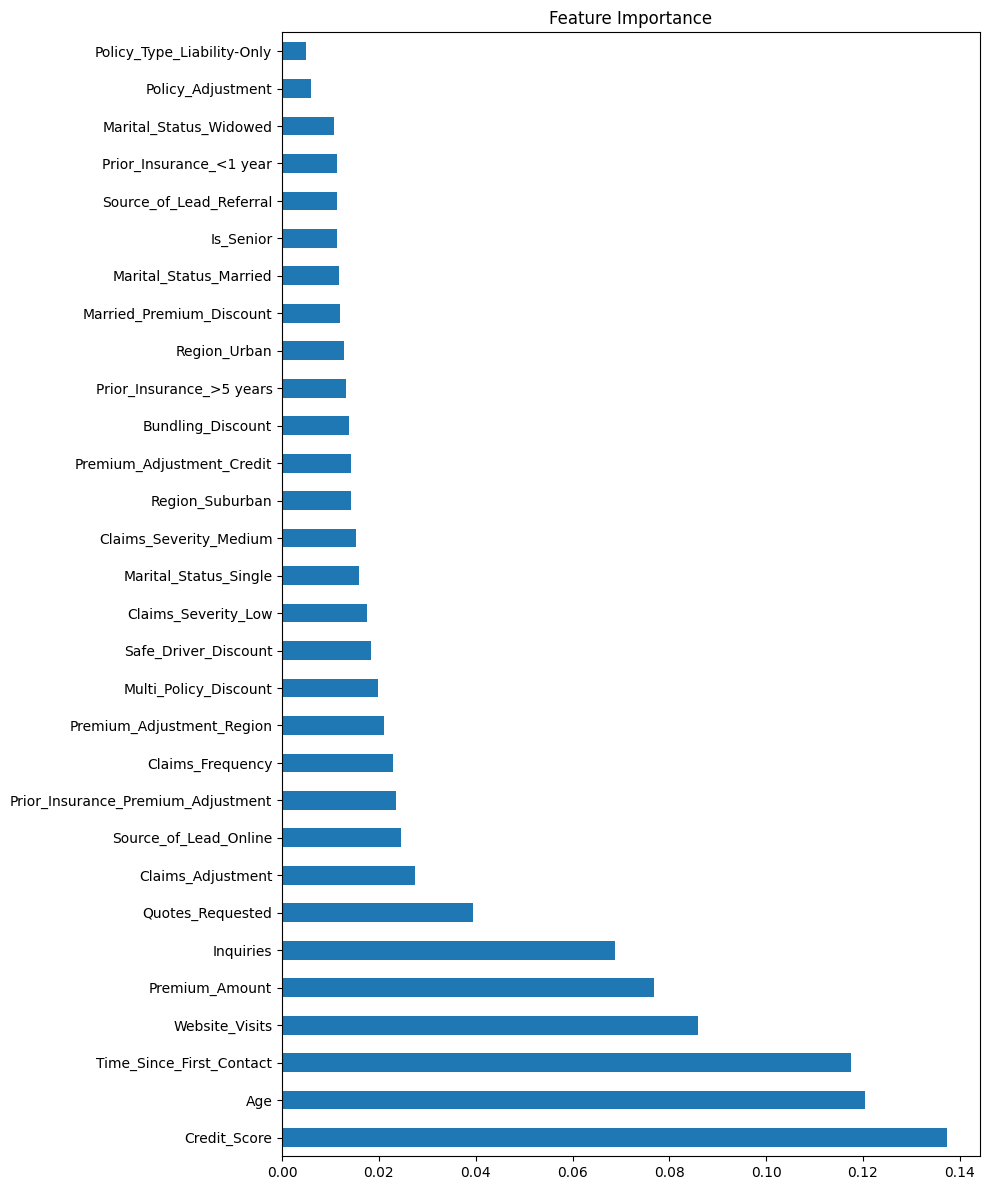

In [20]:
# feature importance

feat_imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
feat_imp.plot(kind='barh', figsize=(10, 12))
plt.title("Feature Importance")
plt.tight_layout()
plt.show()

## Phase 4: Model Evaluation

### Baseline Results

All three models scored ROC AUC of 0.50 — equivalent to random chance.
This is not a code error but a data limitation. The synthetic dataset contains 
weak signal — no single feature strongly separates converters from non-converters,
as confirmed during EDA.

Feature importance analysis reveals `Credit_Score`, `Age`, and 
`Time_Since_First_Contact` as the top three predictors, yet their importance 
scores are spread thinly across all 30 features — confirming no dominant signal exists.

This is a realistic outcome in insurance data and demonstrates the importance 
of EDA before modelling — the results were predictable from the distributions alone.

## Phase 5: Hyperparameter Tuning

We tune the Random Forest Classifier using GridSearchCV to search for the 
best combination of hyperparameters and attempt to improve beyond the baseline.

In [36]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print(f"Best ROC AUC: {grid_search.best_score_:.2f}")

best_rf = grid_search.best_estimator_
y_pred_best = best_rf.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred_best):.2f}")
print("Classification Report: \n", classification_report(y_test, y_pred_best))
print(f"ROC AUC Score: {roc_auc_score(y_test, y_pred_best):.2f}")

Best Parameters: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}
Best ROC AUC: 0.53
Accuracy: 0.57
Classification Report: 
               precision    recall  f1-score   support

           0       0.53      0.07      0.12       860
           1       0.58      0.96      0.72      1140

    accuracy                           0.57      2000
   macro avg       0.55      0.51      0.42      2000
weighted avg       0.56      0.57      0.46      2000

ROC AUC Score: 0.51


## Task 2: Premium Amount Prediction - Regression

We now treat this as a regression problem, predicting the continuous 
`Premium_Amount` using the same dataset. We use Random Forest Regressor 
and XGBoost Regressor and evaluate using RMSE and R² score.

In [21]:
# separate features and target
X2 = df_final.drop(["Conversion_Status", "Premium_Amount"], axis=1)
y2 = df_final["Premium_Amount"]

# scale numeric features
scaler = StandardScaler()
X2_scaled = scaler.fit_transform(X2)

In [22]:
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# train test split
X2_train, X2_test, y2_train, y2_test = train_test_split(X2_scaled, y2, test_size=0.2, random_state=42)

# instantiate all three models
rfr = RandomForestRegressor()
xgbr = XGBRegressor()

In [25]:
# fit the RandomForestRegressor model
rfr.fit(X2_train, y2_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [26]:
# fit the XGBRegressor model
xgbr.fit(X2_train, y2_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_met

In [27]:
# get the predictions for the two models
rfr_pred = rfr.predict(X2_test)
xgbr_pred = xgbr.predict(X2_test)

In [30]:
# evaluation
from sklearn.metrics import mean_squared_error, r2_score

# evaluate the RandomForestRegressor model
print("RandomForestRegressor Model Evaluation")
print(f"Mean Squared Error: {mean_squared_error(y2_test, rfr_pred):.2f}")
print(f"R2 Score: {r2_score(y2_test, rfr_pred):.2f}\n")

# evaluate the XGBRegressor Model
print("XGBRegressor Model Evaluation")
print(f"Mean Squared Error: {mean_squared_error(y2_test, xgbr_pred):.2f}")
print(f"R2 Score: {r2_score(y2_test, xgbr_pred):.2f}")

RandomForestRegressor Model Evaluation
Mean Squared Error: 290.70
R2 Score: 0.99

XGBRegressor Model Evaluation
Mean Squared Error: 64.83
R2 Score: 1.00


### Evaluation Insights
We trained Random Forest Regressor and XGBoost Regressor to predict `Premium_Amount`.

**Results:**
- Random Forest — MSE: 290.70, R²: 0.99
- XGBoost — MSE: 64.83, R²: ~1.00

**Critical finding:** The near-perfect R² reveals that `Premium_Amount` is largely 
a computed column — derived directly from adjustment and discount features already 
present in the dataset. The model is reverse-engineering a pricing formula rather 
than learning a generalizable real-world pattern. In production, this would be 
flagged and investigated before deployment.

## Project Summary

This project built a full machine learning pipeline on synthetic insurance data.

**Task 1 — Conversion Prediction (Classification):**
- All models scored ROC AUC ~0.50 — equivalent to random chance.
- EDA confirmed weak signal — no feature strongly separates converters 
  from non-converters in this synthetic dataset.
- Hyperparameter tuning via GridSearchCV was applied to Random Forest 
  to attempt performance improvement.
- `Credit_Score`, `Age`, and `Time_Since_First_Contact` were the 
  most important features.

**Task 2 — Premium Amount Prediction (Regression):**
- Random Forest R²: 0.99 | XGBoost R²: ~1.00
- Near-perfect scores revealed `Premium_Amount` is a computed column 
  derived from adjustment features — reverse-engineering a formula, 
  not real prediction.

**Key Lessons:**
- EDA findings predicted model outcomes before any model was trained.
- Target leakage (`Time_to_Conversion`) was identified and removed early.
- Perfect or near-perfect scores are red flags, not celebrations.
- Weak signal in synthetic data is a realistic and important outcome 
  to understand and communicate professionally.